In [2]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_groq import ChatGroq

from langchain.messages import RemoveMessage

In [3]:
load_dotenv()

True

In [ ]:
model = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [24]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [25]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [26]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [27]:
graph = builder.compile(checkpointer=InMemorySaver())

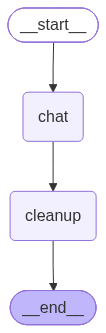

In [28]:
graph

In [29]:
config = {"configurable": {"thread_id": "t1"}}

In [34]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Ansh"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [AIMessage(content="LangChain! That's a fascinating topic. LangChain is an open-source framework for building and deploying large language models, with a focus on modularity, scalability, and ease of use. Here's what I know about LangChain:\n\n**What is LangChain?**\n\nLangChain is a framework that allows developers to build and deploy large language models using a modular and scalable architecture. It provides a set of tools and libraries that make it easy to develop, train, and deploy language models, as well as integrate them with other applications and services.\n\n**Key Features of LangChain:**\n\n1. **Modular architecture**: LangChain provides a modular architecture that allows developers to build and deploy language models using a variety of components, such as models, datasets, and training scripts.\n2. **Scalability**: LangChain is designed to scale with large language models, making it easy to train and deploy models with billions of parameters.\n3. **Ease of use

In [35]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 7
